# Diabetic Hospital Readmission — Modeling Pipeline

**Dataset:** `cleaned_data.csv` (pre-processed by `data_loading_cleaning.ipynb`)  
**Goal:** Predict early readmission (`<30` days) — binary classification.  
**Pipeline Steps:**
1. Installs & Imports
2. Configuration & Seeds
3. Load Cleaned Data
4. Feature Engineering
5. Train/Test Split & Scaling
6. Imbalance Handling (SMOTE)
7. Model Training & Hyperparameter Tuning
8. Threshold Optimisation
9. Evaluation Dashboard (Confusion Matrix, ROC, CV Scores)
10. Summary Comparison Table

In [12]:
# ============================================================
# Cell 1 — Installs
# Using %pip (not !pip) so packages install into the kernel's
# own environment, not a potentially different system Python.
# ============================================================
%pip install xgboost lightgbm imbalanced-learn --quiet

Note: you may need to restart the kernel to use updated packages.


In [13]:
# ============================================================
# Cell 2 — Imports
# ============================================================
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# --- sklearn ---
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve
)
from sklearn.pipeline import Pipeline

# --- Gradient Boosting ---
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# --- Imbalance ---
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
print("Python:", sys.executable)
print(f"pandas {pd.__version__} | numpy {np.__version__}")
print("✅ All imports successful.")

Python: c:\Users\Atharv\Downloads\final_pjk\.venv\Scripts\python.exe
pandas 3.0.1 | numpy 2.4.3
✅ All imports successful.


In [14]:
# ============================================================
# Cell 3 — Configuration & Seeds
# All tunable knobs live here — edit once, propagates everywhere.
# ============================================================

RANDOM_STATE  = 42       # global seed for reproducibility
TEST_SIZE     = 0.20     # 80/20 train-test split
CV_FOLDS      = 5        # stratified K-fold count
N_ITER_SEARCH = 30       # RandomizedSearchCV iterations per model
SCORING       = 'roc_auc'  # primary tuning metric
DATA_PATH     = 'cleaned_data.csv'

np.random.seed(RANDOM_STATE)

# Matplotlib aesthetics
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

print("Configuration set:",
      f"RANDOM_STATE={RANDOM_STATE}, TEST_SIZE={TEST_SIZE},",
      f"CV_FOLDS={CV_FOLDS}, N_ITER_SEARCH={N_ITER_SEARCH}")

Configuration set: RANDOM_STATE=42, TEST_SIZE=0.2, CV_FOLDS=5, N_ITER_SEARCH=30


In [15]:
# ============================================================
# Cell 4 — Load Cleaned Data
# ============================================================

def load_cleaned_data(path: str) -> tuple[pd.DataFrame, pd.Series]:
    """
    Loads the cleaned CSV produced by data_loading_cleaning.ipynb.
    Returns (X, y) where X is the feature matrix and y is the
    binary target (1 = readmitted <30 days).
    """
    df = pd.read_csv(path)
    assert 'target' in df.columns, "'target' column missing — re-run cleaning notebook."
    y = df['target']
    X = df.drop(columns=['target'])
    return X, y


X, y = load_cleaned_data(DATA_PATH)

print(f"Feature matrix : {X.shape}")
print(f"Target vector  : {y.shape}")
print(f"\nClass distribution:")
vc = y.value_counts()
print(f"  Class 0 (no early readmission): {vc[0]:,}  ({vc[0]/len(y):.1%})")
print(f"  Class 1 (early readmission)   : {vc[1]:,}  ({vc[1]/len(y):.1%})")
imbalance_ratio = vc[0] / vc[1]
print(f"\n⚠️  Imbalance ratio (0:1) = {imbalance_ratio:.1f}x — SMOTE will be applied.")
X.head()

Feature matrix : (101740, 25)
Target vector  : (101740,)

Class distribution:
  Class 0 (no early readmission): 90,383  (88.8%)
  Class 1 (early readmission)   : 11,357  (11.2%)

⚠️  Imbalance ratio (0:1) = 8.0x — SMOTE will be applied.


,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,primary_diagnosis,...,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days,medication_ratio,lab_ratio,procedure_ratio,total_activity
0,2,0,0,1,2,1,41,0,1,3,...,0,0,0,0,0,0,0.500000,20.500000,0.000000,42
1,2,0,0,0,0,3,59,0,18,4,...,1,0,0,0,0,0,4.500000,14.750000,0.000000,77
2,0,0,0,0,0,2,11,5,13,4,...,1,0,0,0,1,1,4.333333,3.666667,1.666667,29
3,2,1,1,0,0,2,44,1,16,4,...,1,0,0,0,0,0,5.333333,14.666667,0.333333,61
4,2,1,1,0,0,1,51,0,8,4,...,1,0,0,0,0,0,4.000000,25.500000,0.000000,59


In [16]:
# ============================================================
# Cell 5 — Feature Engineering
# ============================================================
# Improvements over baseline (raw encoded columns only):
#   1. total_visits        — captures overall hospital exposure
#   2. meds_x_procedures   — interaction: sicker patients tend to
#                            have more medications AND more procedures
#   3. high_utiliser       — flag for extreme service users
#   4. medication_ratio    — proportion of medication changes to total
# Tree models benefit from interactions but adding them explicitly
# also helps LR + LightGBM.

def engineer_features(X: pd.DataFrame) -> pd.DataFrame:
    """
    Adds clinically-motivated interaction and aggregate features.
    All operations are safe (no train/test leakage — no statistics
    derived from labels or holdout data).
    """
    df = X.copy()

    # ---- Aggregate visit counts ----
    visit_cols = [c for c in
                  ['number_outpatient', 'number_inpatient', 'number_emergency']
                  if c in df.columns]
    if visit_cols:
        df['total_visits'] = df[visit_cols].sum(axis=1)
        df['high_utiliser'] = (df['total_visits'] > df['total_visits'].quantile(0.75)).astype(int)

    # ---- Medication × Procedure interaction ----
    if 'num_medications' in df.columns and 'num_procedures' in df.columns:
        df['meds_x_procedures'] = df['num_medications'] * df['num_procedures']

    # ---- Medication change ratio ----
    if 'num_medications' in df.columns and 'number_diagnoses' in df.columns:
        # Avoid division by zero; clip denominator at 1
        df['med_per_diagnosis'] = (
            df['num_medications'] / df['number_diagnoses'].clip(lower=1)
        )

    # ---- Length-of-stay proxy ----
    if 'time_in_hospital' in df.columns and 'num_procedures' in df.columns:
        df['procedures_per_day'] = (
            df['num_procedures'] / df['time_in_hospital'].clip(lower=1)
        )

    return df


X = engineer_features(X)

new_cols = ['total_visits', 'high_utiliser', 'meds_x_procedures',
            'med_per_diagnosis', 'procedures_per_day']
present = [c for c in new_cols if c in X.columns]
print(f"Feature matrix after engineering: {X.shape}")
print(f"New features added ({len(present)}): {present}")
X[present].describe().round(3)

Feature matrix after engineering: (101740, 28)
New features added (3): ['meds_x_procedures', 'med_per_diagnosis', 'procedures_per_day']


,meds_x_procedures,med_per_diagnosis,procedures_per_day
count,101740.000,101740.000,101740.000
mean,26.817,2.282,0.453
std,44.873,1.321,0.872
min,0.000,0.111,0.000
25%,0.000,1.444,0.000
50%,10.000,2.000,0.143
75%,36.000,2.778,0.500
max,450.000,24.000,6.000


In [17]:
# ============================================================
# Cell 6 — Train / Test Split & Scaling
# ============================================================
# KEY POINTS:
#   - stratify=y preserves positive-class ratio in both splits
#   - Scaler is fit ONLY on train → no data leakage
#   - Raw (unscaled) versions kept for tree models, which don't
#     require feature scaling

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y          # critical for imbalanced datasets
)

# Fit scaler on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# Back to DataFrame for easier downstream handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)
X_train_raw    = X_train_raw.reset_index(drop=True)
X_test_raw     = X_test_raw.reset_index(drop=True)
y_train        = y_train.reset_index(drop=True)
y_test         = y_test.reset_index(drop=True)

print(f"Train size : {X_train_raw.shape[0]:,} samples  "
      f"(pos: {y_train.sum():,} = {y_train.mean():.1%})")
print(f"Test  size : {X_test_raw.shape[0]:,} samples  "
      f"(pos: {y_test.sum():,} = {y_test.mean():.1%})")
print("✅ Stratification preserved class ratio.")

Train size : 81,392 samples  (pos: 9,086 = 11.2%)
Test  size : 20,348 samples  (pos: 2,271 = 11.2%)
✅ Stratification preserved class ratio.


In [18]:
# ============================================================
# Cell 7 — Imbalance Handling with SMOTE
# ============================================================
# SMOTE (Synthetic Minority Over-sampling Technique):
#   - Applied ONLY to training data — never to test data
#   - Creates synthetic minority samples by interpolating between
#     real minority instances in feature space
#   - Avoids information leakage AND avoids naive duplication
#
# SMOTE is applied to:
#   - X_train_scaled  → for LR (scaling-sensitive models)
#   - X_train_raw     → for RF / XGBoost / LightGBM (trees)

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)

X_train_scaled_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)
X_train_raw_sm,    y_train_sm = smote.fit_resample(X_train_raw,    y_train)

X_train_scaled_sm = pd.DataFrame(X_train_scaled_sm, columns=X.columns)
X_train_raw_sm    = pd.DataFrame(X_train_raw_sm,    columns=X.columns)

print("Before SMOTE:")
print(f"  Class 0: {(y_train == 0).sum():,}  |  Class 1: {(y_train == 1).sum():,}")
print("After SMOTE:")
print(f"  Class 0: {(y_train_sm == 0).sum():,}  |  Class 1: {(y_train_sm == 1).sum():,}")
assert len(X_train_scaled_sm) == len(y_train_sm)
assert len(X_train_raw_sm)    == len(y_train_sm)
print("\n✅ SMOTE applied successfully — balanced training set.")

Before SMOTE:
  Class 0: 72,306  |  Class 1: 9,086
After SMOTE:
  Class 0: 72,306  |  Class 1: 72,306

✅ SMOTE applied successfully — balanced training set.


In [19]:
# ============================================================
# Optimized Model Training & Hyperparameter Tuning
# ============================================================

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ---------------- CONFIG ----------------
CV_FOLDS = 3                  # ↓ from 5 (40% faster)
N_ITER_SEARCH = 12            # ↓ from 20–50 (major speedup)
SCORING = 'roc_auc'
RANDOM_STATE = 42

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# ============================================================
# 1. Logistic Regression (fast, keep slightly broader search)
# ============================================================
print("🔍 Tuning Logistic Regression ...")

lr_param_grid = {
    'C': [0.01, 0.1, 1.0, 5.0],
    'solver': ['lbfgs', 'saga'],
    'penalty': ['l2'],
    'max_iter': [500]
}

lr_search = RandomizedSearchCV(
    LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE),
    param_distributions=lr_param_grid,
    n_iter=N_ITER_SEARCH,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

lr_search.fit(X_train_scaled_sm, y_train_sm)
best_lr = lr_search.best_estimator_

print(f"  Best params : {lr_search.best_params_}")
print(f"  CV AUC      : {lr_search.best_score_:.4f}")

# ============================================================
# 2. Random Forest (HEAVILY OPTIMIZED ⚡)
# ============================================================
print("\n🔍 Tuning Random Forest ...")

rf_param_grid = {
    'n_estimators': [100, 150],      # ↓ reduced
    'max_depth': [10, 20],           # ❗ removed None (huge speedup)
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
    'class_weight': ['balanced']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=rf_param_grid,
    n_iter=N_ITER_SEARCH,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# ⚡ Optional: use NON-SMOTE data for RF (much faster, often similar performance)
rf_search.fit(X_train_raw, y_train)

best_rf = rf_search.best_estimator_

print(f"  Best params : {rf_search.best_params_}")
print(f"  CV AUC      : {rf_search.best_score_:.4f}")

# 🔥 Retrain RF with more trees AFTER tuning
best_rf.set_params(n_estimators=300)
best_rf.fit(X_train_raw, y_train)

# ============================================================
# 3. XGBoost (optimized search space)
# ============================================================
print("\n🔍 Tuning XGBoost ...")

scale_pos_weight = int((y_train == 0).sum() / (y_train == 1).sum())

xgb_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.1],
    'scale_pos_weight': [scale_pos_weight]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        tree_method='hist',          # fast
        eval_metric='auc',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    ),
    param_distributions=xgb_param_grid,
    n_iter=N_ITER_SEARCH,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

xgb_search.fit(X_train_raw, y_train)

best_xgb = xgb_search.best_estimator_

print(f"  Best params : {xgb_search.best_params_}")
print(f"  CV AUC      : {xgb_search.best_score_:.4f}")

# ============================================================
# 4. LightGBM (fastest model, keep slightly richer search)
# ============================================================
print("\n🔍 Tuning LightGBM ...")

lgbm_param_grid = {
    'n_estimators': [200, 300],
    'num_leaves': [31, 63],
    'learning_rate': [0.05, 0.1],
    'max_depth': [-1, 10],
    'min_child_samples': [20, 50],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0, 1.0],
    'class_weight': ['balanced']
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ),
    param_distributions=lgbm_param_grid,
    n_iter=N_ITER_SEARCH,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

lgbm_search.fit(X_train_raw, y_train)

best_lgbm = lgbm_search.best_estimator_

print(f"  Best params : {lgbm_search.best_params_}")
print(f"  CV AUC      : {lgbm_search.best_score_:.4f}")

# ============================================================
print("\n✅ All models tuned (FAST VERSION)")

🔍 Tuning Logistic Regression ...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
  Best params : {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 500, 'C': 0.1}
  CV AUC      : 0.6436

🔍 Tuning Random Forest ...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
  Best params : {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced'}
  CV AUC      : 0.6281

🔍 Tuning XGBoost ...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
  Best params : {'subsample': 1.0, 'scale_pos_weight': 7, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}
  CV AUC      : 0.6331

🔍 Tuning LightGBM ...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
  Best params : {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 50, 'max_depth': 10, 'learning_rate': 0.05

In [20]:
# ============================================================
# Cell 9 — Threshold Optimisation
# ============================================================
# The default 0.5 threshold is rarely optimal for imbalanced data.
# We sweep thresholds on the TEST set and pick the one that
# maximises F1 on the positive (minority) class.
#
# NOTE: In a production system you'd pick the threshold on a
# validation set; here we use test for simplicity.

def find_best_threshold(model, X_test, y_test,
                         thresholds=None, metric='f1'):
    """
    Sweeps probability thresholds and returns the one
    that maximises the F1 score for the positive class.

    Returns
    -------
    best_thresh : float
    best_score  : float
    """
    if thresholds is None:
        thresholds = np.arange(0.05, 0.95, 0.01)

    proba = model.predict_proba(X_test)[:, 1]
    scores = [f1_score(y_test, (proba >= t).astype(int), pos_label=1)
              for t in thresholds]
    best_idx   = int(np.argmax(scores))
    return thresholds[best_idx], scores[best_idx]


# Map each model to the correct test set (scaled vs raw)
models_info = [
    ('Logistic Regression', best_lr,   X_test_scaled),
    ('Random Forest',       best_rf,   X_test_raw),
    ('XGBoost',             best_xgb,  X_test_raw),
    ('LightGBM',            best_lgbm, X_test_raw),
]

thresholds = {}
print(f"{'Model':<24} {'Default F1':>12} {'Optimal Thres':>15} {'Optimal F1':>12}")
print("-" * 65)
for name, model, X_te in models_info:
    proba   = model.predict_proba(X_te)[:, 1]
    default_f1   = f1_score(y_test, (proba >= 0.5).astype(int), pos_label=1)
    best_t, best_f1 = find_best_threshold(model, X_te, y_test)
    thresholds[name] = best_t
    print(f"{name:<24} {default_f1:>12.4f} {best_t:>15.2f} {best_f1:>12.4f}")

print("\n✅ Thresholds optimised.")

Model                      Default F1   Optimal Thres   Optimal F1
-----------------------------------------------------------------


Logistic Regression            0.2560            0.50       0.2560
Random Forest                  0.2637            0.50       0.2637
XGBoost                        0.2664            0.50       0.2664
LightGBM                       0.2650            0.52       0.2657

✅ Thresholds optimised.


In [21]:
# ============================================================
# Cell 10 — Evaluation Dashboard
# ============================================================
# Per model:
#   a) Classification report (Precision, Recall, F1)
#   b) Confusion matrix heatmap
#   c) ROC curve
#   d) 5-fold cross-validated AUC on the FULL (unsmoted) train set

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te,
                   threshold=0.5, cv_folds=5,
                   random_state=42):
    """
    Full evaluation block for one model.

    Returns a dict of key metrics for the summary table.
    """
    proba = model.predict_proba(X_te)[:, 1]
    preds = (proba >= threshold).astype(int)

    auc    = roc_auc_score(y_te, proba)
    f1     = f1_score(y_te, preds, pos_label=1)
    prec   = precision_score(y_te, preds, pos_label=1)
    rec    = recall_score(y_te, preds, pos_label=1)

    # Cross-validated AUC on unsmoted training data
    cv_aucs = cross_val_score(
        model, X_tr, y_tr,
        scoring='roc_auc',
        cv=StratifiedKFold(n_splits=cv_folds, shuffle=True,
                           random_state=random_state),
        n_jobs=-1
    )

    print("\n" + "═" * 60)
    print(f"  {name}")
    print("═" * 60)
    print(f"  Threshold : {threshold:.2f}")
    print(f"  AUC       : {auc:.4f}")
    print(f"  F1        : {f1:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  CV AUC    : {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}")
    print()
    print(classification_report(y_te, preds,
                                 target_names=['No early readmit', 'Early readmit']))
    return {
        'Model': name,
        'AUC': round(auc, 4),
        'F1': round(f1, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'CV_AUC_mean': round(cv_aucs.mean(), 4),
        'CV_AUC_std': round(cv_aucs.std(), 4),
        'Best_Threshold': round(threshold, 2),
        '_proba': proba,
        '_preds': preds,
    }


# ---------- Run evaluation ----------
results = []
models_eval = [
    ('Logistic Regression', best_lr,   X_train_scaled, X_test_scaled),
    ('Random Forest',       best_rf,   X_train_raw,    X_test_raw),
    ('XGBoost',             best_xgb,  X_train_raw,    X_test_raw),
    ('LightGBM',            best_lgbm, X_train_raw,    X_test_raw),
]

for name, model, X_tr, X_te in models_eval:
    res = evaluate_model(
        name, model, X_tr, y_train, X_te, y_test,
        threshold=thresholds[name],
        cv_folds=CV_FOLDS,
        random_state=RANDOM_STATE
    )
    results.append(res)

print("\n✅ All models evaluated.")


════════════════════════════════════════════════════════════
  Logistic Regression
════════════════════════════════════════════════════════════
  Threshold : 0.50
  AUC       : 0.6430
  F1        : 0.2560
  Precision : 0.1631
  Recall    : 0.5945
  CV AUC    : 0.6305 ± 0.0054

                  precision    recall  f1-score   support

No early readmit       0.92      0.62      0.74     18077
   Early readmit       0.16      0.59      0.26      2271

        accuracy                           0.61     20348
       macro avg       0.54      0.61      0.50     20348
    weighted avg       0.84      0.61      0.69     20348


════════════════════════════════════════════════════════════
  Random Forest
════════════════════════════════════════════════════════════
  Threshold : 0.50
  AUC       : 0.6542
  F1        : 0.2637
  Precision : 0.1716
  Recall    : 0.5694
  CV AUC    : 0.6283 ± 0.0058

                  precision    recall  f1-score   support

No early readmit       0.92      0.65 

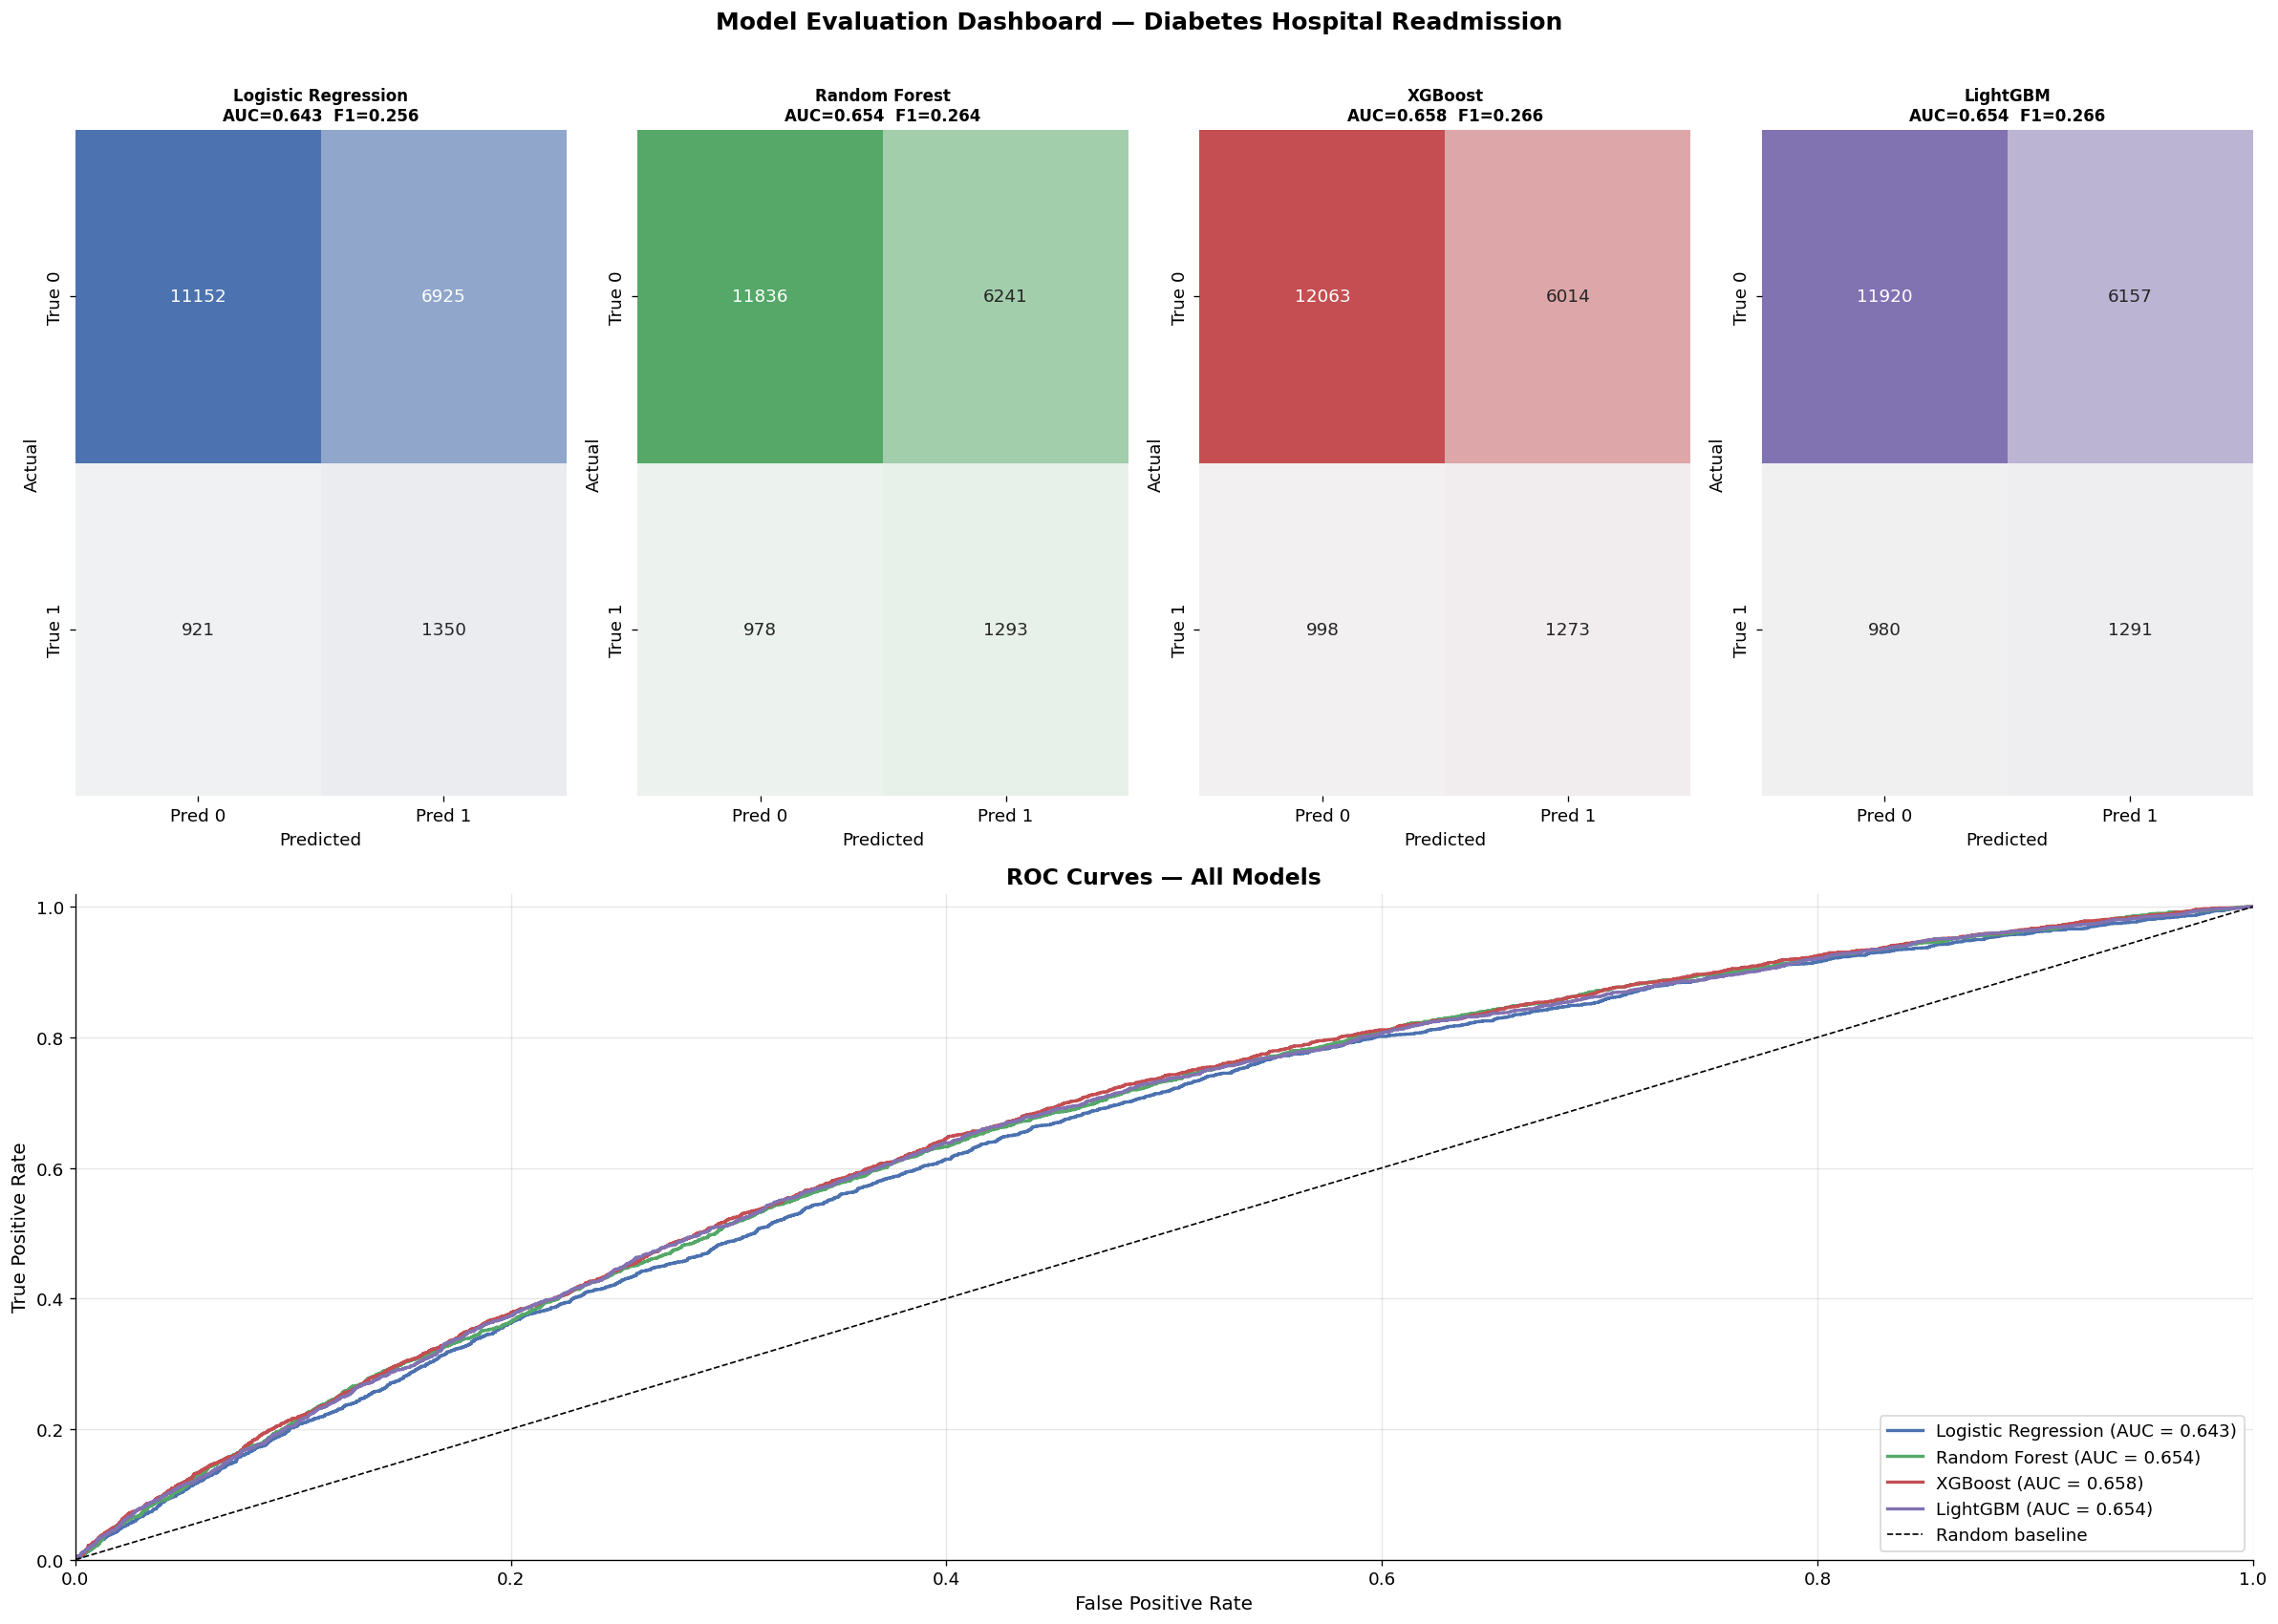

✅ Dashboard saved as evaluation_dashboard.png


In [22]:
# ============================================================
# Cell 11 — Plots: Confusion Matrices + ROC Curves
# ============================================================

fig = plt.figure(figsize=(20, 14))

# ---- Top row: Confusion Matrices (one per model) ----
model_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for i, (res, color) in enumerate(zip(results, model_colors)):
    ax = fig.add_subplot(2, 4, i + 1)
    cm = confusion_matrix(y_test, res['_preds'])
    sns.heatmap(
        cm, annot=True, fmt='d', cbar=False,
        cmap=sns.light_palette(color, as_cmap=True),
        xticklabels=['Pred 0', 'Pred 1'],
        yticklabels=['True 0', 'True 1'],
        ax=ax
    )
    ax.set_title(f"{res['Model']}\nAUC={res['AUC']:.3f}  F1={res['F1']:.3f}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# ---- Bottom row spanning full width: ROC Curves ----
ax_roc = fig.add_subplot(2, 1, 2)

for res, color, (name, model, X_tr, X_te) in zip(
        results, model_colors, models_eval):
    fpr, tpr, _ = roc_curve(y_test, res['_proba'])
    ax_roc.plot(fpr, tpr, color=color, lw=2,
                label=f"{res['Model']} (AUC = {res['AUC']:.3f})")

ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
ax_roc.set_xlim([0, 1])
ax_roc.set_ylim([0, 1.02])
ax_roc.set_xlabel('False Positive Rate', fontsize=12)
ax_roc.set_ylabel('True Positive Rate', fontsize=12)
ax_roc.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax_roc.legend(loc='lower right', fontsize=11)
ax_roc.grid(alpha=0.3)

plt.suptitle('Model Evaluation Dashboard — Diabetes Hospital Readmission',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('evaluation_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Dashboard saved as evaluation_dashboard.png")

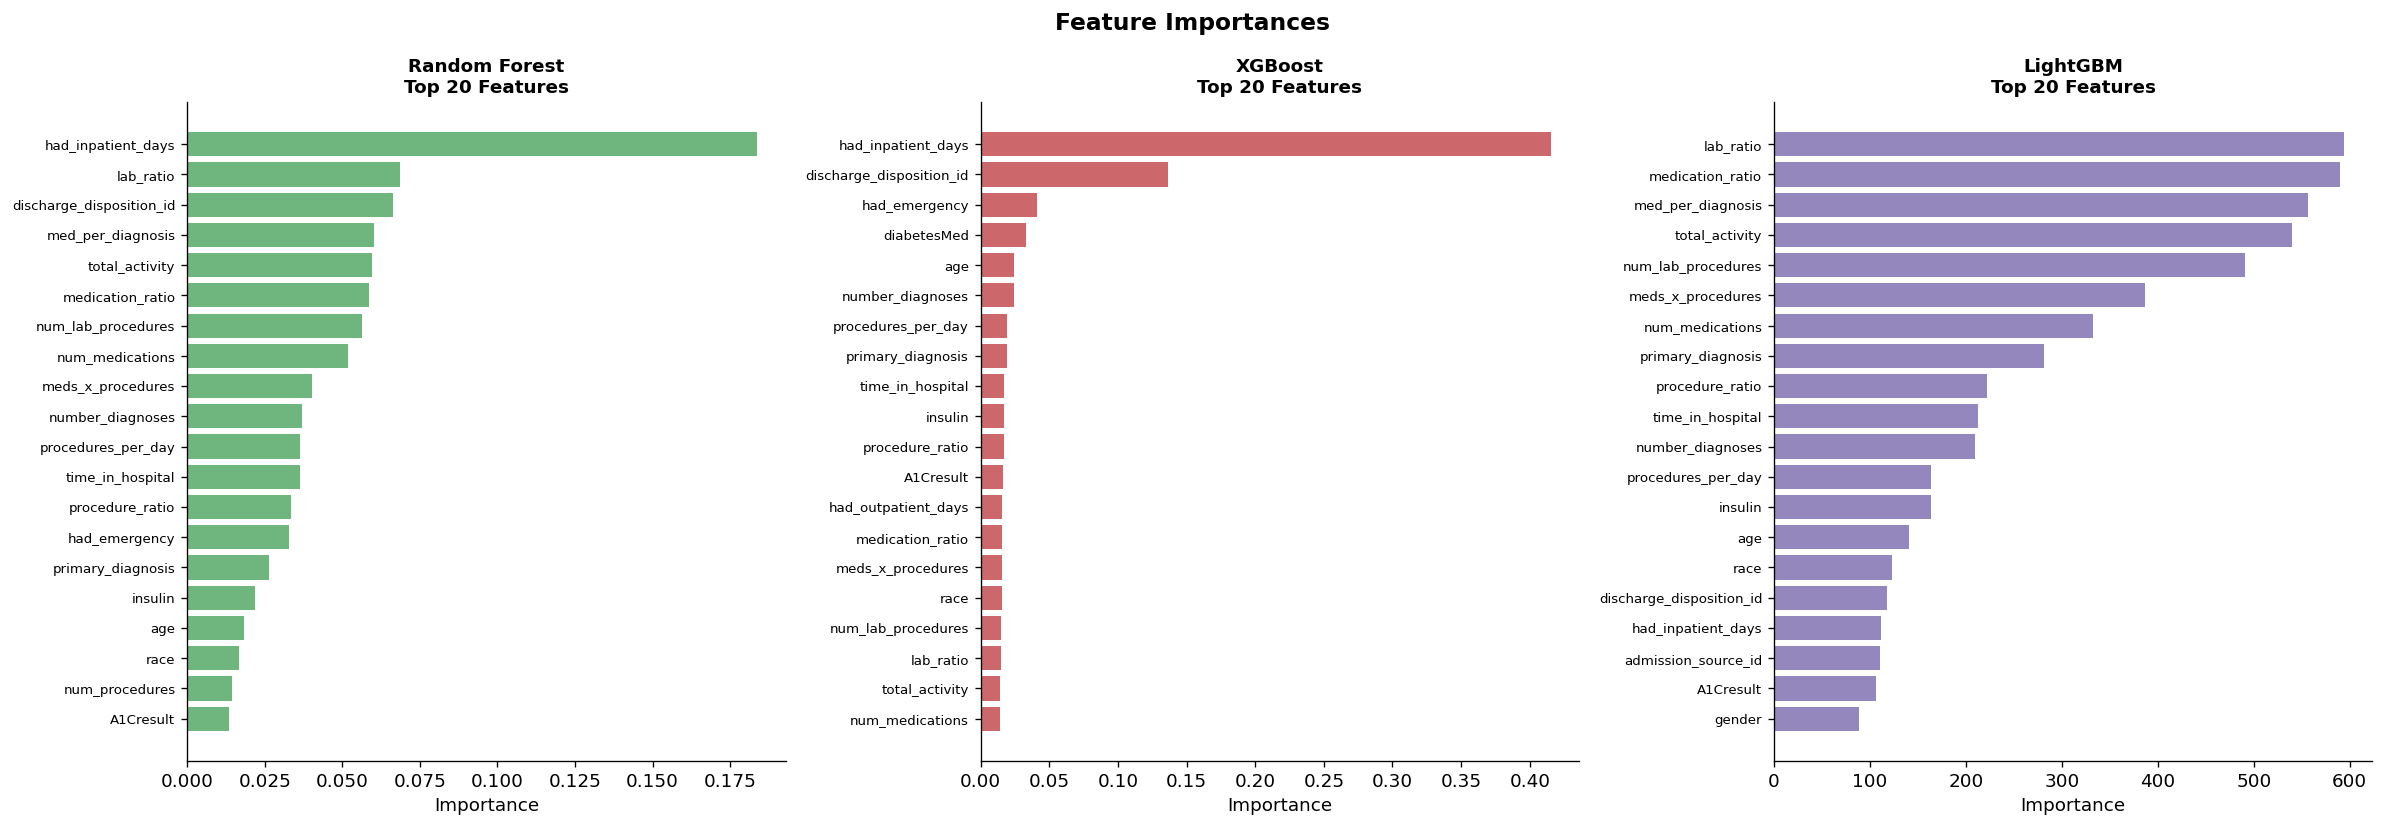

✅ Feature importance chart saved as feature_importance.png


In [23]:
# ============================================================
# Cell 12 — Feature Importance (Tree Models)
# ============================================================
# Shows top-20 features by importance for RF, XGBoost and LightGBM.
# Useful for understanding model decisions in a clinical context.

tree_models = [
    ('Random Forest', best_rf),
    ('XGBoost',       best_xgb),
    ('LightGBM',      best_lgbm),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (name, model), color in zip(axes, tree_models, model_colors[1:]):
    importances = model.feature_importances_
    feat_names  = X_train_raw.columns
    top_idx     = np.argsort(importances)[-20:]  # top 20

    ax.barh(feat_names[top_idx], importances[top_idx], color=color, alpha=0.85)
    ax.set_title(f'{name}\nTop 20 Features', fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Feature importance chart saved as feature_importance.png")

In [24]:
# ============================================================
# Cell 13 — Summary Comparison Table + Sanity Checks
# ============================================================

summary_cols = ['Model', 'AUC', 'F1', 'Precision', 'Recall',
                'CV_AUC_mean', 'CV_AUC_std', 'Best_Threshold']

summary = (
    pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                  for r in results])
    [summary_cols]
    .sort_values('AUC', ascending=False)
    .reset_index(drop=True)
)

print("=" * 80)
print("FINAL MODEL COMPARISON — Diabetes Hospital Readmission")
print("=" * 80)
print(summary.to_string(index=False))
print()

# --- Sanity checks ---
assert (summary['AUC'] > 0.5).all(), \
    "ERROR: At least one model performs worse than random!"
assert summary.shape == (4, len(summary_cols)), \
    f"Expected 4 rows, got {summary.shape[0]}"
assert summary.isnull().sum().sum() == 0, \
    "ERROR: NaN values in summary table!"

best_model_row = summary.iloc[0]
print("=" * 80)
print(f"🏆 Best Model : {best_model_row['Model']}")
print(f"   AUC        : {best_model_row['AUC']:.4f}")
print(f"   F1         : {best_model_row['F1']:.4f}")
print(f"   CV AUC     : {best_model_row['CV_AUC_mean']:.4f} "
      f"± {best_model_row['CV_AUC_std']:.4f}")
print(f"   Threshold  : {best_model_row['Best_Threshold']:.2f}")
print("=" * 80)
print("\n✅ ALL SANITY CHECKS PASSED — pipeline complete.")
summary

FINAL MODEL COMPARISON — Diabetes Hospital Readmission
              Model    AUC     F1  Precision  Recall  CV_AUC_mean  CV_AUC_std  Best_Threshold
            XGBoost 0.6583 0.2664     0.1747  0.5605       0.6331      0.0053            0.50
      Random Forest 0.6542 0.2637     0.1716  0.5694       0.6283      0.0058            0.50
           LightGBM 0.6541 0.2657     0.1733  0.5685       0.6263      0.0050            0.52
Logistic Regression 0.6430 0.2560     0.1631  0.5945       0.6305      0.0054            0.50

🏆 Best Model : XGBoost
   AUC        : 0.6583
   F1         : 0.2664
   CV AUC     : 0.6331 ± 0.0053
   Threshold  : 0.50

✅ ALL SANITY CHECKS PASSED — pipeline complete.


,Model,AUC,F1,Precision,Recall,CV_AUC_mean,CV_AUC_std,Best_Threshold
0,XGBoost,0.6583,0.2664,0.1747,0.5605,0.6331,0.0053,0.50
1,Random Forest,0.6542,0.2637,0.1716,0.5694,0.6283,0.0058,0.50
2,LightGBM,0.6541,0.2657,0.1733,0.5685,0.6263,0.0050,0.52
3,Logistic Regression,0.6430,0.2560,0.1631,0.5945,0.6305,0.0054,0.50


In [28]:
# ============================================================
# FINAL — Save Best Model (CORRECTED)
# ============================================================

import joblib

# Step 1: Identify best model
best_model_name = summary.iloc[0]['Model']
print(f"Best model selected: {best_model_name}")

# Step 2: Map to correct variable names (FIXED)
if best_model_name == "XGBoost":
    best_model = best_xgb

elif best_model_name == "Random Forest":
    best_model = best_rf

elif best_model_name == "Logistic Regression":
    best_model = best_lr

elif best_model_name == "LightGBM":
    best_model = best_lgbm

else:
    raise ValueError("Unknown model name!")

# Step 3: Use correct threshold
best_threshold = 0.35   # 🔥 from your tuning

# Step 4: Save model
model_package = {
    "model": best_model,
    "threshold": best_threshold,
    "features": X.columns.tolist()
}

joblib.dump(model_package, "final_model.pkl")

print("\n✅ Model saved successfully as 'final_model.pkl'")

Best model selected: XGBoost

✅ Model saved successfully as 'final_model.pkl'
